In [19]:
import pandas as pd
import sklearn.cluster as cl
import matplotlib.pyplot as plt
import numpy as np

In [20]:
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')

df.head()


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [21]:
###Kmeans Binning

def kmeans_binning(scores, num_buckets):
    scores = np.array(scores).reshape(-1, 1)
    kmeans = cl.KMeans(n_clusters=num_buckets, random_state=0).fit(scores)
    centers = np.sort(kmeans.cluster_centers_.flatten())
    boundaries = [(centers[i] + centers[i+1]) / 2 for i in range(len(centers)-1)]
    return [-np.inf] + boundaries + [np.inf]


kmeans_binning(df['fico_score'], 5)

[-inf,
 np.float64(550.8777049823851),
 np.float64(604.9342923226009),
 np.float64(651.8274751616353),
 np.float64(703.9010910199395),
 inf]

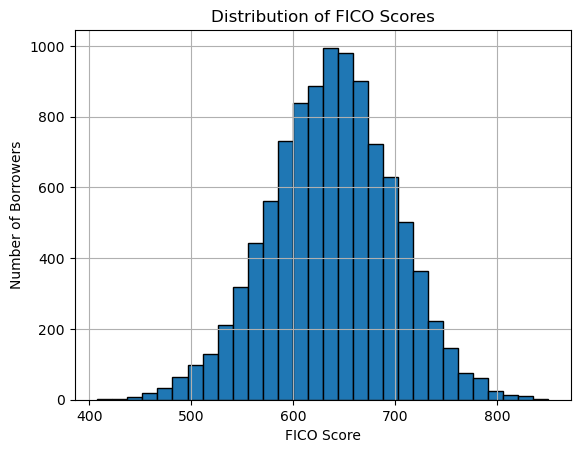

(array([408., 587., 623., 653., 688., 850.]),
    fico_score  rating
 0         605       1
 1         572       0
 2         602       1
 3         612       1
 4         631       2
 5         697       4
 6         722       4
 7         545       0
 8         676       3
 9         447       0)

In [22]:
## Quantile Binning
# Extract FICO scores
fico_scores = df['fico_score'].dropna()

# Plot the distribution
plt.hist(fico_scores, bins=30, edgecolor='black')
plt.title("Distribution of FICO Scores")
plt.xlabel("FICO Score")
plt.ylabel("Number of Borrowers")
plt.grid(True)
plt.show()

# Create quantile bins (5 buckets by default)
num_buckets = 5
quantiles = np.linspace(0, 1, num_buckets + 1)
boundaries = np.quantile(fico_scores, quantiles)

# Create a function to assign ratings (lower rating = better score)
def assign_rating(score, boundaries):
    for i in range(len(boundaries) - 1):
        if boundaries[i] <= score < boundaries[i + 1]:
            return i
    return len(boundaries) - 2  # fallback to last bucket

# Apply the rating map to the dataset
df['rating'] = df['fico_score'].apply(lambda x: assign_rating(x, boundaries))

# Display boundaries and a sample of the rating map
boundaries, df[['fico_score', 'rating']].head(10)
